# What Drives Movie Revenue and Popularity?
## An investigation of the TMDb movie dataset

**Author:** Devin Thomas  
**Course:** Introduction to Data Analysis with Pandas and NumPy

## Introduction

### Dataset description

This report analyzes the cleaned TMDb movie dataset supplied for the project. It contains 10,866 movies released from 1960 through 2015, with fields for budget, revenue, popularity, audience ratings, runtime, release date, and pipe-separated genres. Budget and revenue ending in `_adj` are expressed in 2010 dollars, which makes financial comparisons across years more meaningful.

### Questions

1. How are adjusted budget, runtime, audience rating, and popularity associated with adjusted revenue?
2. Which genres are most popular, and did the popularity of the leading genres change over time?

These are descriptive questions. The dataset is observational, so the results identify patterns and associations rather than causes.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 25)

DATA_PATH = Path("tmdb-movies.csv")
movies_raw = pd.read_csv(DATA_PATH)
movies_raw.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,monster|dna|tyrannosaurus rex|velociraptor|island,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,future|chase|post-apocalyptic|dystopia|australia,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,based on novel|revolution|dystopia|sequel|dyst...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,android|spaceship|jedi|space opera|3d,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,car race|speed|revenge|suspense|car,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


## Data Wrangling

I first inspect the table's size, data types, missingness, duplicate rows, and the zero values in financial fields. A zero budget or revenue is not credible as a measured production total and is treated as missing for financial analysis rather than as a real value.

In [2]:
print(f"Rows: {movies_raw.shape[0]:,}; columns: {movies_raw.shape[1]}")
display(movies_raw.dtypes.to_frame("dtype"))
display(movies_raw.isna().sum().sort_values(ascending=False).head(10).to_frame("missing"))
print(f"Duplicate rows: {movies_raw.duplicated().sum()}")
display((movies_raw[["budget_adj", "revenue_adj", "runtime"]] == 0).sum().to_frame("zero_values"))

Rows: 10,866; columns: 21


,dtype
id,int64
imdb_id,str
popularity,float64
budget,int64
revenue,int64
original_title,str
cast,str
homepage,str
director,str
tagline,str


,missing
homepage,7930
tagline,2824
keywords,1493
production_companies,1030
cast,76
director,44
genres,23
imdb_id,10
overview,4
revenue,0


Duplicate rows: 1


,zero_values
budget_adj,5696
revenue_adj,6016
runtime,31


### Data cleaning

The analysis removes the single duplicate, parses release dates, and replaces zero budget, revenue, and runtime values with missing values. Records are not discarded globally: each analysis uses the subset needed for its variables. Genre values are split into a separate long-form table so that each movie-genre membership forms one row.

In [3]:
movies = movies_raw.drop_duplicates().copy()
movies["release_date"] = pd.to_datetime(movies["release_date"], format="%m/%d/%y", errors="coerce")
movies["release_year"] = movies["release_date"].dt.year.astype("Int64")

for column in ["budget", "revenue", "budget_adj", "revenue_adj", "runtime"]:
    movies[column] = movies[column].replace(0, np.nan)

movies["profit_adj"] = movies["revenue_adj"] - movies["budget_adj"]

genre_movies = (
    movies.dropna(subset=["genres"])
    .assign(genre=lambda frame: frame["genres"].str.split("|"))
    .explode("genre")
)

assert movies.duplicated().sum() == 0
assert movies["release_year"].notna().all()
assert not (movies[["budget_adj", "revenue_adj", "runtime"]] == 0).any().any()
print(f"Clean movie rows: {len(movies):,}")
print(f"Movie-genre rows: {len(genre_movies):,}")

Clean movie rows: 10,865
Movie-genre rows: 26,955


## Exploratory Data Analysis

The helper below is deliberately reused so every chart has consistent titles and axis labels.

In [4]:
def label_plot(ax, title, xlabel, ylabel):
    # Apply a consistent title and axis labels to a Matplotlib axis.
    ax.set_title(title, weight="bold", pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    return ax

### Question 1: How are movie attributes associated with adjusted revenue?

Adjusted revenue is strongly right-skewed, so I begin with a one-variable view on a logarithmic scale. I then compare revenue with budget, popularity, rating, and runtime using correlations and bivariate plots.

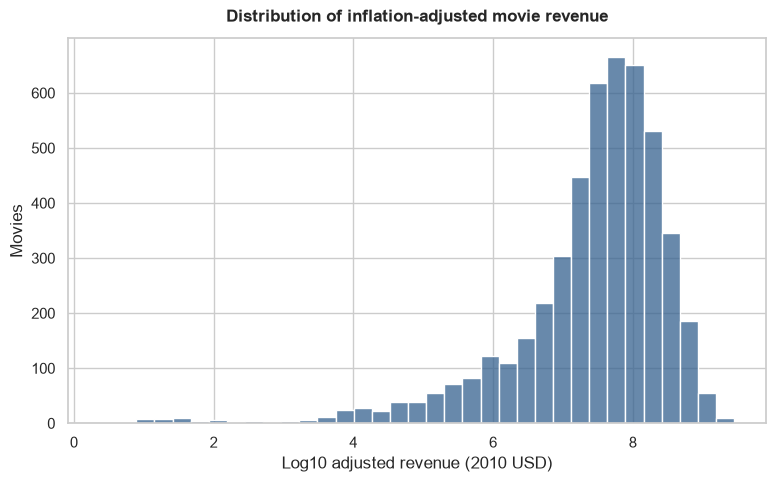

,adjusted_revenue
count,4.849000e+03
mean,1.151009e+08
std,1.988557e+08
min,2.370705e+00
25%,1.046585e+07
50%,4.395666e+07
75%,1.316482e+08
90%,3.066471e+08
max,2.827124e+09


In [5]:
revenue = movies["revenue_adj"].dropna()
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(np.log10(revenue), bins=35, color="#35618f", ax=ax)
label_plot(ax, "Distribution of inflation-adjusted movie revenue", "Log10 adjusted revenue (2010 USD)", "Movies")
plt.show()

revenue.describe(percentiles=[0.25, 0.5, 0.75, 0.9]).to_frame("adjusted_revenue")

,revenue_adj
revenue_adj,1.000000
budget_adj,0.655707
popularity,0.608489
runtime,0.284467
vote_average,0.239815


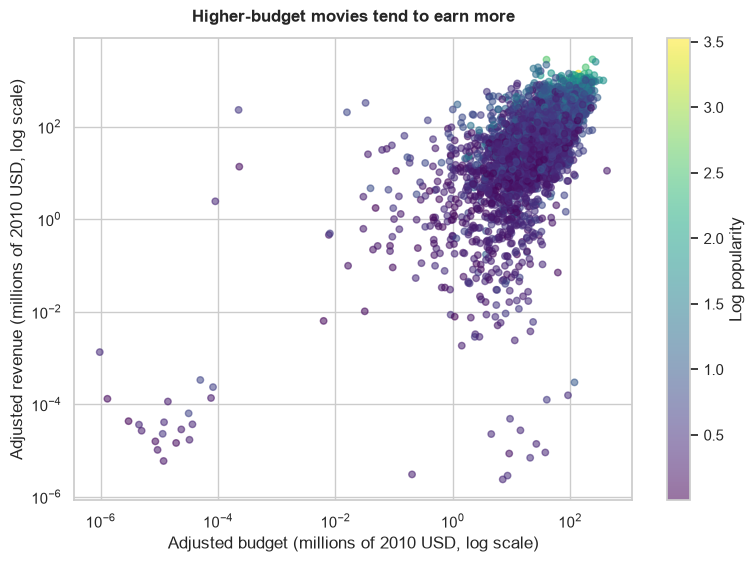

In [6]:
financial = movies.dropna(subset=["budget_adj", "revenue_adj", "popularity"]).copy()
correlations = financial[["revenue_adj", "budget_adj", "popularity", "vote_average", "runtime"]].corr(method="spearman")
display(correlations[["revenue_adj"]].sort_values("revenue_adj", ascending=False))

fig, ax = plt.subplots(figsize=(9, 6))
points = ax.scatter(
    financial["budget_adj"] / 1_000_000,
    financial["revenue_adj"] / 1_000_000,
    c=np.log1p(financial["popularity"]),
    cmap="viridis",
    alpha=0.55,
    s=22,
)
ax.set_xscale("log")
ax.set_yscale("log")
label_plot(ax, "Higher-budget movies tend to earn more", "Adjusted budget (millions of 2010 USD, log scale)", "Adjusted revenue (millions of 2010 USD, log scale)")
colorbar = fig.colorbar(points, ax=ax)
colorbar.set_label("Log popularity")
plt.show()

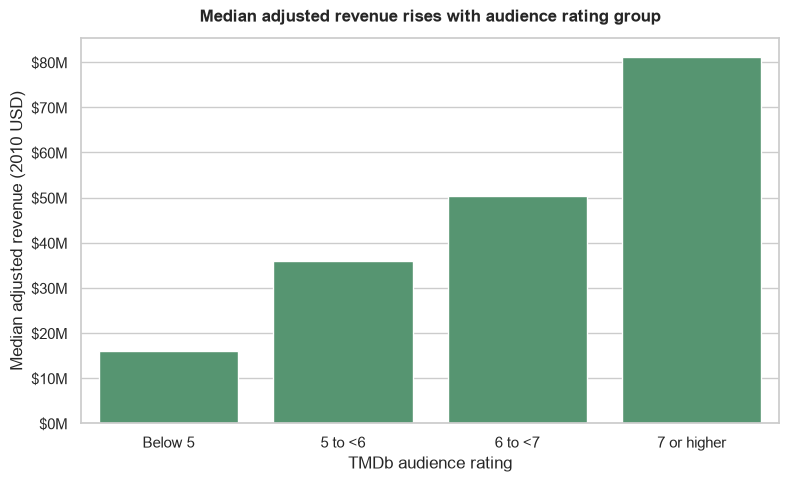

,median,movies
rating_group,,
Below 5,1.601609e+07,341
5 to <6,3.599505e+07,1531
6 to <7,5.039413e+07,2211
7 or higher,8.123695e+07,766


In [7]:
rating_groups = pd.cut(
    movies["vote_average"],
    bins=[0, 5, 6, 7, 10],
    labels=["Below 5", "5 to <6", "6 to <7", "7 or higher"],
    right=False,
)
rating_revenue = (
    movies.assign(rating_group=rating_groups)
    .dropna(subset=["rating_group", "revenue_adj"])
    .groupby("rating_group", observed=True)["revenue_adj"]
    .agg(median="median", movies="size")
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=rating_revenue.reset_index(), x="rating_group", y="median", color="#4c9f70", ax=ax)
ax.yaxis.set_major_formatter(lambda value, _: f"${value / 1_000_000:.0f}M")
label_plot(ax, "Median adjusted revenue rises with audience rating group", "TMDb audience rating", "Median adjusted revenue (2010 USD)")
plt.show()
rating_revenue

Adjusted revenue spans several orders of magnitude. In the subset with reported financial data, budget has the strongest monotonic association with revenue; popularity is also positively associated. The scatter plot still shows substantial variation at any budget level, so budget alone does not determine earnings. Movies rated 7 or higher have a larger median adjusted revenue than lower-rated groups, but the analysis cannot establish whether ratings influence revenue or simply reflect other differences among films.

### Question 2: Which genres are most popular, and how did leading genres change over time?

Because one movie can belong to several genres, each membership contributes to its genre's summary. I require at least 100 movies for the overall ranking so a small category cannot lead because of a few unusual titles.

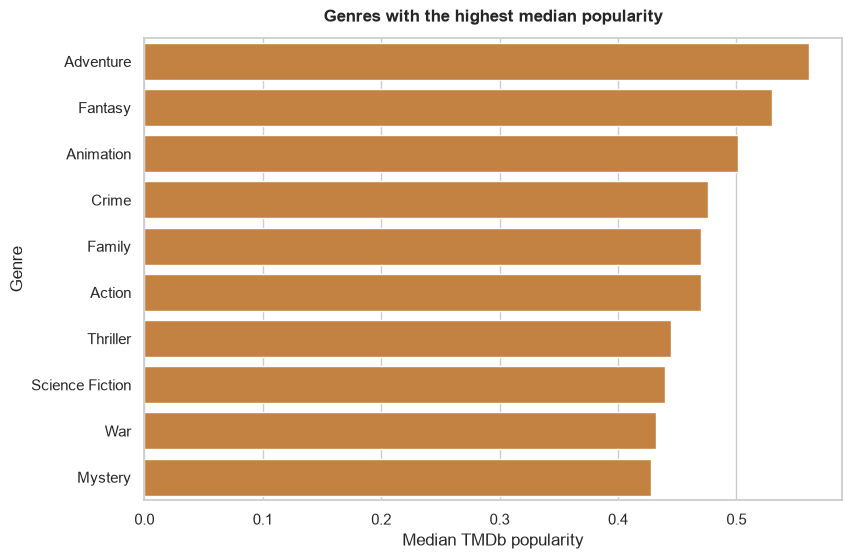

,median_popularity,mean_popularity,movies
genre,,,
Adventure,0.561034,1.154259,1471
Fantasy,0.530123,0.992840,916
Animation,0.501163,0.852182,699
Crime,0.476338,0.744930,1354
Family,0.470249,0.786668,1231
Action,0.469825,0.926274,2384
Thriller,0.444337,0.741563,2907
Science Fiction,0.439600,1.001548,1229
War,0.432470,0.727683,270


In [8]:
genre_summary = (
    genre_movies.groupby("genre")["popularity"]
    .agg(median_popularity="median", mean_popularity="mean", movies="size")
    .query("movies >= 100")
    .sort_values("median_popularity", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    data=genre_summary.head(10).reset_index(),
    y="genre",
    x="median_popularity",
    color="#d9822b",
    ax=ax,
)
label_plot(ax, "Genres with the highest median popularity", "Median TMDb popularity", "Genre")
plt.show()
genre_summary.head(10)

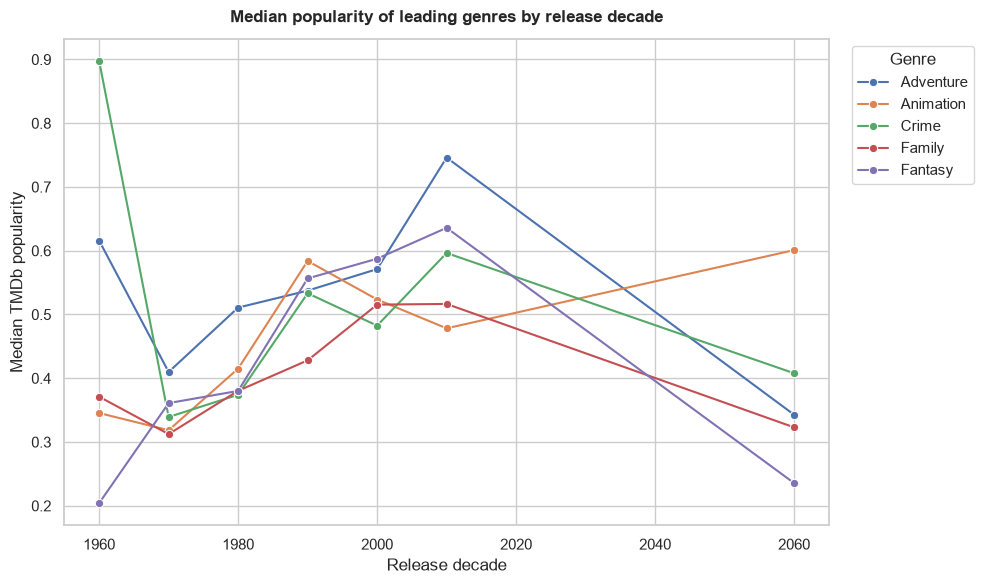

In [9]:
top_genres = genre_summary.head(5).index
genre_decades = (
    genre_movies[genre_movies["genre"].isin(top_genres)]
    .assign(decade=lambda frame: (frame["release_year"] // 10 * 10).astype(int))
    .query("decade >= 1960")
    .groupby(["decade", "genre"])["popularity"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=genre_decades, x="decade", y="popularity", hue="genre", marker="o", ax=ax)
label_plot(ax, "Median popularity of leading genres by release decade", "Release decade", "Median TMDb popularity")
ax.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Adventure, Fantasy, Animation, Crime, and Family lead the large-genre ranking by median popularity. The decade view shows that the absolute popularity metric is generally higher for recent films, especially for Adventure and Fantasy. This likely reflects both genuine audience interest and how TMDb's popularity score is constructed and observed; comparisons across distant decades should therefore be treated cautiously.

## Conclusions and Limitations

The analysis found a positive association between adjusted budget and adjusted revenue, with popularity also related to revenue. Higher audience-rating groups had larger median revenue, although wide variation remained within every group. Adventure and Fantasy were the two most popular well-represented genres by median TMDb popularity, and their median popularity was highest in recent decades.

Several limitations matter. Budget and revenue are missing for many movies and are likely not missing at random; TMDb popularity is a platform-specific, time-sensitive score; one film contributes to every listed genre; and the data ends in 2015. The observational design also cannot support causal claims. Additional research could use a more complete financial source, adjust for release scale and marketing, and compare genre trends using a stable measure such as inflation-adjusted box office per theater or a fixed post-release audience window.